# Cloud Adoption and Business Efficiency Prediction

## Objective
This project predicts whether business efficiency improves after adopting cloud computing.

## Dataset
Dataset used: **business_cloud_efficiency_dataset.csv**

- cloud_adoption (0/1)
- usage_frequency (1–5)
- training (0/1)
- integration (0/1)
- efficiency (0/1) → target

## Model
Logistic Regression is used because the target variable is binary.

In [1]:
# Google Colab file upload
from google.colab import files
uploaded = files.upload()

Saving business_cloud_efficiency_dataset.csv to business_cloud_efficiency_dataset.csv


In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [4]:
# Load dataset
df = pd.read_csv("business_cloud_efficiency_dataset.csv")
df.head()

,cloud_adoption,usage_frequency,training,integration,efficiency
0,0,1,0,0,0
1,1,1,1,0,1
2,0,3,1,1,1
3,0,2,1,1,1
4,0,5,0,0,1


In [5]:
# Check basic information
print("Shape of dataset:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)

Shape of dataset: (300, 5)

Missing values:
 cloud_adoption     0
usage_frequency    0
training           0
integration        0
efficiency         0
dtype: int64

Data types:
 cloud_adoption     int64
usage_frequency    int64
training           int64
integration        int64
efficiency         int64
dtype: object


In [6]:
# Summary statistics
df.describe()

,cloud_adoption,usage_frequency,training,integration,efficiency
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,0.496667,2.970000,0.440000,0.510000,0.500000
std,0.500824,1.422149,0.497216,0.500735,0.500835
min,0.000000,1.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000,0.000000,0.000000
50%,0.000000,3.000000,0.000000,1.000000,0.500000
75%,1.000000,4.000000,1.000000,1.000000,1.000000
max,1.000000,5.000000,1.000000,1.000000,1.000000


## Data Visualization

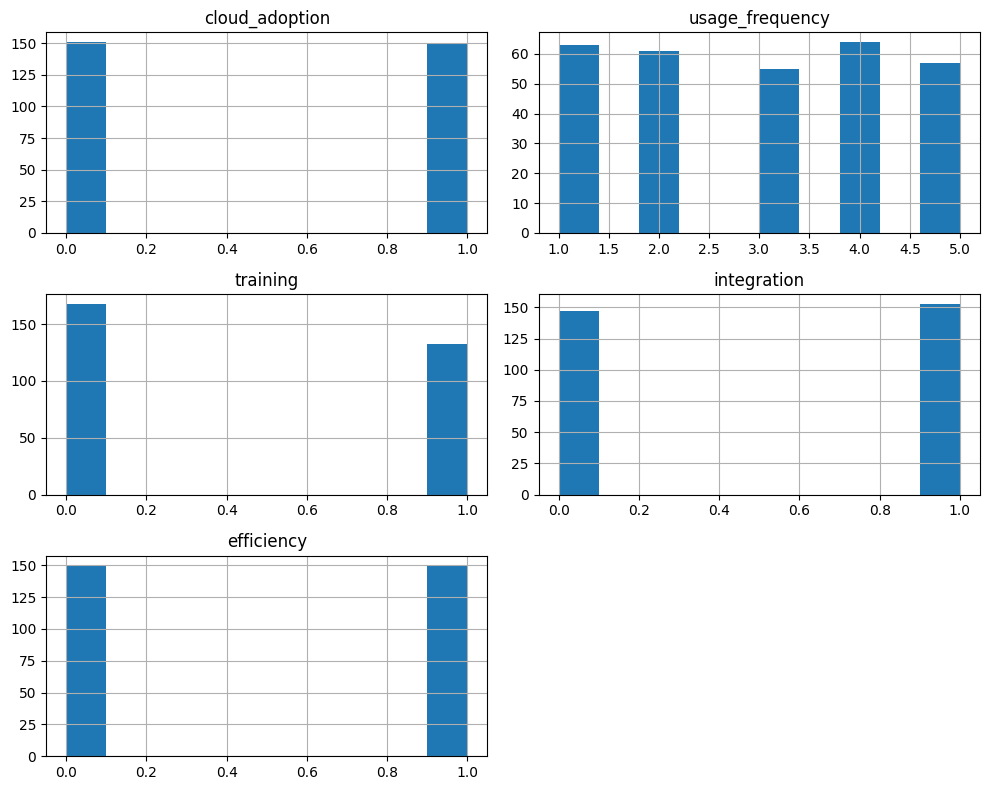

In [7]:
# Histogram of all numerical variables
df.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

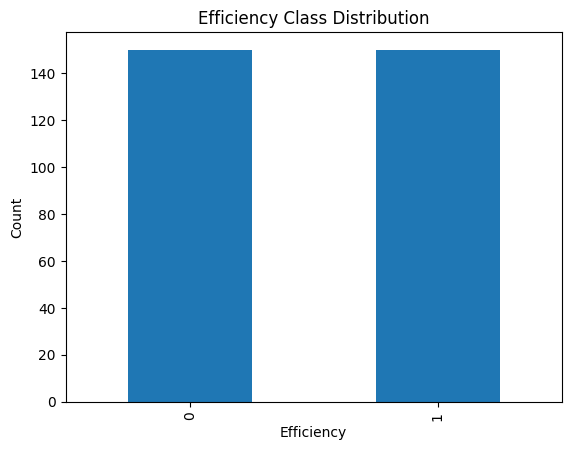

In [8]:
# Efficiency class distribution
df["efficiency"].value_counts().plot(kind="bar")
plt.title("Efficiency Class Distribution")
plt.xlabel("Efficiency")
plt.ylabel("Count")
plt.show()

In [9]:
# Prepare features and target
X = df.drop("efficiency", axis=1)
y = df["efficiency"]

print("Features:\n", X.head())
print("\nTarget:\n", y.head())

Features:
    cloud_adoption  usage_frequency  training  integration
0               0                1         0            0
1               1                1         1            0
2               0                3         1            1
3               0                2         1            1
4               0                5         0            0

Target:
 0    0
1    1
2    1
3    1
4    1
Name: efficiency, dtype: int64


In [10]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (240, 4)
Testing set shape: (60, 4)


In [11]:
# Train logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [12]:
# Predict classes and probabilities
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

## Model Evaluation

In [13]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 4))

Accuracy: 0.7


In [14]:
# Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.66      0.83      0.74        30
           1       0.77      0.57      0.65        30

    accuracy                           0.70        60
   macro avg       0.72      0.70      0.69        60
weighted avg       0.72      0.70      0.69        60



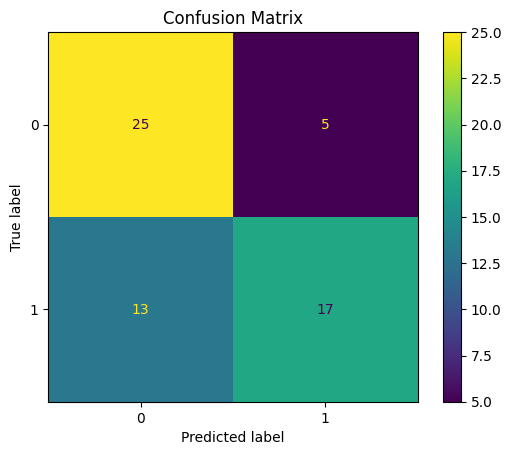

In [15]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

## Feature Importance

In [17]:
# Logistic regression coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

print(coefficients)

           Feature  Coefficient
0   cloud_adoption     1.208738
1  usage_frequency     0.590235
3      integration     0.522585
2         training     0.505105


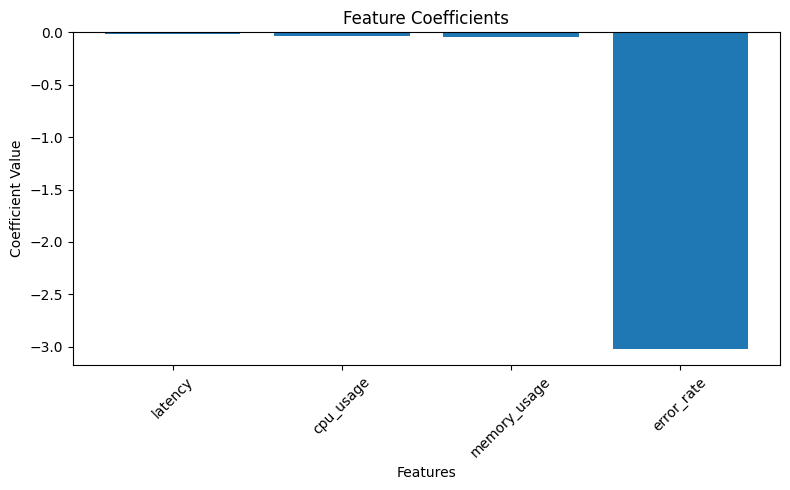

In [ ]:
# Plot feature coefficients
plt.figure(figsize=(8,5))
plt.bar(coefficients["Feature"], coefficients["Coefficient"])
plt.title("Feature Coefficients")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Interpretation

- Positive coefficient → increases chance of efficiency
- Negative coefficient → decreases chance of efficiency

## Final Conclusion

This study demonstrates that cloud computing adoption has a positive impact on business efficiency.  
Using logistic regression, we analyzed how factors such as cloud adoption, usage frequency, training, and integration influence operational efficiency.

The results indicate that businesses are more likely to become efficient when they actively adopt cloud technologies, use them regularly, train their employees, and integrate them well with existing processes.

Hence, cloud computing can be considered an important driver of operational efficiency in modern business environments.
